## Download GHCNd station data

This script downloads GHCNd station data
<br>
and puts desired variables and quality flags
<br>
in a (station, time) netcdf file.  


v1.0 pulls data from Minnesota stations only  
v1.0 designates the very first iteration that has no (known) bugs   
v1.0 should contribute to a reproducible workflow on any machine with the other 1.0 notebooks

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

KeyboardInterrupt: 

In [ ]:
# create data directory structure
data_dir = Path("../station_data/ghcnd")
data_dir.mkdir(parents=True, exist_ok=True)

# netcdf save name
output_nc = data_dir / "first_order_stations.nc"

In [ ]:
print(data_dir.resolve())

C:\Users\wesja\Desktop\MCAP\MCAP_ENSO_PROJECT\station_data\ghcnd


In [ ]:
# station codes for the 9 first order stations
first_order_stations = ['USW00014926', 'USW00014922',
                        'USW00014918', 'USW00014913',
                        'USW00014925', 'USW00014916',
                        'USW00014944', 'USW00014914',
                        'USW00014920']

In [ ]:
# relevant GHCNd variables
# convert to millimeters and Celsius
# precip and liquid precip equivalent are in tenths of millimeters
target_vars = ["TMAX", "TMIN", "PRCP", "MDPR", "DAPR",
               "SNOW", "MDSF", "DASF", "SNWD", "WESD", "WESF"]

temp_conv = 0.1
mm0p1 = 0.1
mm = 1
var_conv = {"TMAX": temp_conv,
            "TMIN": temp_conv,
            "PRCP": mm0p1,
            "MDPR": mm0p1,
            "DAPR": 1.0,
            "SNOW": mm,
            "SNWD": mm,
            "MDSF": mm,
            "DASF": 1.0,
            "WESD": mm0p1,
            "WESF": mm0p1}

# make a separate set of quality flag variables
qc_list = [f"{item}_q" for item in target_vars]

In [ ]:
# grab all available data
target_dates = pd.date_range("1890-01-01", pd.Timestamp.today().normalize(), freq="D")

# data dimensions
n_days = len(target_dates)
n_stations = len(first_order_stations)

# set up empty matrices to fill with data and quality flags
data_matrices = {
    var: np.full((n_stations, n_days), np.nan, dtype=np.float32)
    for var in target_vars
}

qc_matrices = {
    var: np.zeros((n_stations, n_days), dtype=bool)
    for var in target_vars
}

In [ ]:
# preprocessing loop

station_ids = []
lats = []
lons = []
station_names = []

for i, station_id in tqdm(enumerate(first_order_stations), total=len(first_order_stations)):
    # don't download station if it already exists
    # delete station file directory to re-download data (e.g. to get latest data)
    local_path = data_dir / f"{station_id}.csv"
    url = f"https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/{station_id}.csv"
    if local_path.exists():
        df = pd.read_csv(local_path, low_memory=False)
    else:
        try:
            df = pd.read_csv(url, low_memory=False)
            df.to_csv(local_path, index=False)
        except Exception as e:
            print(f"Skipping {station_id}: Unexpected error ({e}). Try redownloading later")
            continue

    # station id and lat/lon
    lat = df["LATITUDE"].iloc[0]
    lon = df["LONGITUDE"].iloc[0]
    name = df["NAME"].iloc[0]

    # set dates
    df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
    df = df.dropna(subset=["DATE"]).drop_duplicates(subset=["DATE"])
    df = df.set_index("DATE")
    df_reindexed = df.reindex(target_dates)

    # fill variable matrices
    for var in target_vars:
        if var in df_reindexed.columns:
            vals = pd.to_numeric(df_reindexed[var], errors="coerce")

            # now grab and apply quality/measurement flags
            # grab attribute column
            attr_col = f"{var}_ATTRIBUTES"
            if attr_col in df_reindexed.columns:
                # split "mflag,qflag,sflag,obs_time" columns
                attrs = (
                    df_reindexed[attr_col]
                    .astype(str)
                    .str.split(",", expand=True)
                )

                # measurement flag (mflag) is index 0 
                # quality flag (qflag) is index 1
                mflag = (
                    attrs[0].str.strip()
                    if 0 in attrs.columns
                    else pd.Series("", index=df_reindexed.index)
                )

                # measurement flag. set trace to 0.0
                is_trace = mflag == "T"
                vals[is_trace] = 0

                # look for quality flags
                if 1 in attrs.columns:
                    qflag = (
                        attrs[1]
                        .astype(str)
                        .str.strip()
                        .replace({"": np.nan, "nan": np.nan, "np.nan": np.nan, "None": np.nan})
                    )
                else:
                    qflag = pd.Series(np.nan, index=df_reindexed.index)

            # clean up fill values
            vals = vals.replace(-9999, np.nan)

            # apply unit conversion and save variable
            vals_converted = (var_conv[var] * vals).values.astype(np.float32)
            data_matrices[var][i, :] = vals_converted

            # save qc mask
            # True (bad) False (passed)
            bad_q = qflag.notna()
            qc_matrices[var][i, :] = bad_q

    station_ids.append(station_id)
    lats.append(lat)
    lons.append(lon)
    station_names.append(name)


# save data and metadata
data_vars = {}

for var in target_vars:
    data_vars[var] = (("station", "time"), data_matrices[var])

    data_vars[f"{var}_q"] = (("station", "time"), qc_matrices[var])

desc_txt = "tmax, tmin, precip (PRCP), snowfall (SNOW),"\
                "snow depth (SNWD), and snow water equivalent"\
                " of snowfall (WESF) and snowdepth (WESD)."\
                " Apply QC mask before using data, e.g."\
                " ds['SNOW_cleaned'] = ds['SNOW'].where(~ds['SNOW_q'])."

ds = xr.Dataset(
    data_vars=data_vars,
    coords={
        "station": station_ids,
        "time": target_dates,
        "lat": ("station", lats),
        "lon": ("station", lons),
        "name": ("station", station_names),
    },
    attrs={
        "title": "GHCN-Daily Minnesota and bordering weather stations",
        "Description": desc_txt,
        "date_range": f"{target_dates[0].strftime('%Y-%m-%d')} to {target_dates[-1].strftime('%Y-%m-%d')}",
    },
)

# define addditional time coordinate 'winter-_ear' which is just a calendar where the
# most important season (winter) doesn't have to straddle two years
winter_year = ds.time.dt.year.where(
    ds.time.dt.month < 7,
    ds.time.dt.year + 1
)

ds = ds.assign_coords(winter_year=winter_year)

# set attributes
ds['TMAX'].attrs = {"var": "daily max temperature", "units": "Celsius", "missing_value": np.nan}
ds['TMIN'].attrs = {"var": "daily min temperature", "units": "Celsius", "missing_value": np.nan}
ds['PRCP'].attrs = {"var": "daily total precipitation", "units": "mm", "missing_value": np.nan}
ds['MDPR'].attrs = {"var": "multi-day total precipitation", "units": "mm", "missing_value": np.nan}
ds['DAPR'].attrs = {"var": "multi-day total precipitation number of days summed over", "units": "mm", "missing_value": np.nan}
ds['SNOW'].attrs = {"var": "daily total snowfall", "units": "mm", "missing_value": np.nan}
ds['MDSF'].attrs = {"var": "multi-day total snowfall", "units": "mm", "missing_value": np.nan}
ds['DASF'].attrs = {"var": "multi-day total snowfall number of days summed over", "units": "mm", "missing_value": np.nan}
ds['SNWD'].attrs = {"var": "measured snow pack depth", "units": "mm", "missing_value": np.nan}
ds['WESD'].attrs = {"var": "snow water equivalent of snow pack", "units": "mm", "missing_value": np.nan}
ds['WESF'].attrs = {"var": "snow water equivalent of daily snowfall", "units": "mm", "missing_value": np.nan}

for var in qc_list:
    ds[var].attrs = {"var": f"{var} quality flag. A True value implies quality issues"}

# compression settings
encoding = {
    var: {"zlib": True, "complevel": 1}
    for var in ds.data_vars
}

# save to netcdf
ds.to_netcdf(output_nc, encoding=encoding)

print(f"Dataset saved to '{output_nc}'.")

100%|██████████| 9/9 [00:08<00:00,  1.11it/s]


Dataset saved to '..\station_data\ghcnd\first_order_stations.nc'.


In [ ]:
#quick vis
station_df = ds.to_dataframe().reset_index()
target_vars = ["TMAX", "TMIN", "PRCP", "MDPR", "DAPR",
               "SNOW", "MDSF", "DASF", "SNWD", "WESD", "WESF"]
display(station_df.groupby("station")[target_vars].count()) #table shows n of obs for each variable


,TMAX,TMIN,PRCP,MDPR,DAPR,SNOW,MDSF,DASF,SNWD,WESD,WESF
station,,,,,,,,,,,
USW00014913,28760,28760,28760,0,0,28609,0,0,28608,11449,0
USW00014914,31355,31456,31458,0,0,30917,0,0,29989,9504,0
USW00014916,31101,31100,31100,0,0,31094,0,0,31085,194,0
USW00014918,35112,35178,34942,0,0,31249,0,0,28655,11526,0
USW00014920,32207,32218,32034,0,0,31871,0,0,31691,1050,0
USW00014922,32314,32313,32314,0,0,30975,0,0,31375,9337,0
USW00014925,40475,40479,40226,0,0,37114,0,0,30635,9325,0
USW00014926,31752,31754,32214,1,0,31830,1,0,30140,9537,0
USW00014944,34568,34570,34570,0,0,34503,0,0,33371,8539,0


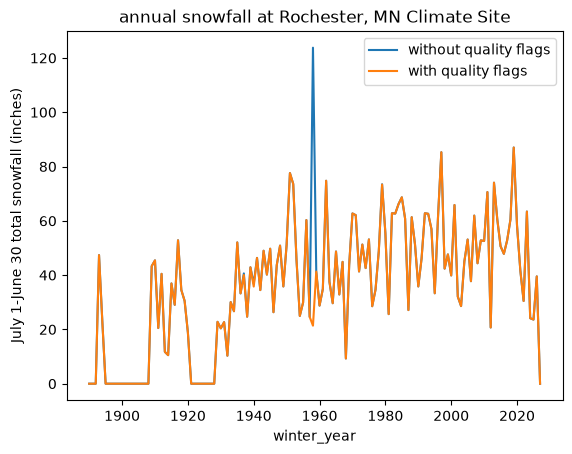

In [ ]:
# quick plot of total winter_year snowfall Rochester snowfall to show importance of quality flags
rochester_snow_raw = ds['SNOW'].sel(station='USW00014925').groupby('winter_year').sum(dim='time')/25.4
rochester_snow_with_qualityflag = (ds['SNOW'].where(~ds['SNOW_q'])).sel(station='USW00014925')
rochester_snow_with_qualityflag = rochester_snow_with_qualityflag.groupby('winter_year').sum(dim='time')/25.4


fig,ax = plt.subplots()
rochester_snow_raw.plot.line(ax=ax, label='without quality flags')
rochester_snow_with_qualityflag.plot(ax=ax, label='with quality flags')
plt.legend()
plt.title('annual snowfall at Rochester, MN Climate Site')
plt.ylabel('July 1-June 30 total snowfall (inches)')
plt.show()

In [ ]:
#combine all station data into one csv
station_df.to_csv(data_dir/'all_station_data.csv', index=False)